In [90]:
import pickle as pkl
import matplotlib.pylab as plt
import numpy as np

In [5]:
from pathlib import Path
home = str(Path.home())

In [83]:
tp = 'RRLYR'
counter = 100
all_bands = False
add_regular_lc = True
batch_n = 2
batch = True
# DSCT_Roman_lc_batch_1_size_100_includes_regular.pkl
if all_bands:
    filename = '%s_Roman_lc_%i_all_bands.pkl' %(tp, counter)
    if add_regular_lc:
        filename = '%s_Roman_lc_%i_all_bands_includes_regular.pkl' %(tp, counter)
else:
    if add_regular_lc:
        if batch:
            filename = '%s_Roman_lc_batch_%i_size_%i_includes_regular.pkl' %(tp, batch_n, counter)
        else:
            filename = '%s_Roman_lc_%i_includes_regular.pkl' %(tp, counter)
    else:
        if batch:
            filename = '%s_Roman_lc_batch_%i_size_%i.pkl' %(tp, batch_n, counter)
        else:
            filename = '%s_Roman_lc_%i.pkl' %(tp, counter)
        
direc = './../output/'+filename

In [84]:
ls

__pycache__/            fix_sampling_all.ipynb  test_gap_reducer.ipynb
code.py                 functions_test.py       test_outputs.ipynb
Fit_Be_stars.ipynb      old_functions.py


In [85]:
Roman_sampling_short = np.load('./../lc_example/roman_times_shortcadence.npy')
Roman_sampling_long = np.load('./../lc_example/roman_times_longcadence.npy')
Roman_sampling_short_min = min(Roman_sampling_short)
Roman_sampling_short = Roman_sampling_short - Roman_sampling_short_min
Roman_sampling_long_min = min(Roman_sampling_long)
Roman_sampling_long = Roman_sampling_long - Roman_sampling_long_min

In [86]:
with open(direc, 'rb') as f:
    all_data = pkl.load(f)

In [87]:
# all_data['OGLE-BLG-RRLYR-03103'].keys()

In [88]:
name = list(all_data.keys())[3]

IndexError: list index out of range

In [89]:
len(list(all_data.keys()))

0

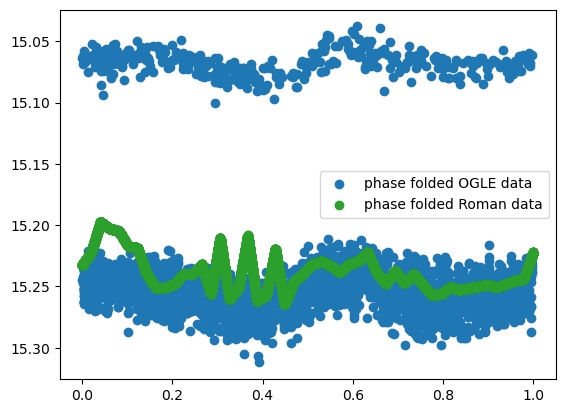

In [82]:
band = 'I'
all_data.keys()
for key in list([name]):
    if not key.startswith('OGLE'):
        continue
    plt.figure()
    tmp_pkl = all_data[key]
    period = tmp_pkl['period']
    plt.scatter((tmp_pkl['%s_band_time_bservation'%band]/period)%1,
    tmp_pkl['%s_band_m_observation'%band], label='phase folded OGLE data')
    # plt.scatter((t_new/period)%1,
    # tmp_pkl['I_band_Roman_with_gaps'])
    # print(len(tmp_pkl['%s_band_Roman_m_regular_sampling'%band]))
    # plt.scatter(tmp_pkl['%s_band_Roman_time_regular_sampling'%band],
    #             tmp_pkl['%s_band_Roman_m_regular_sampling'%band],
    #             s=3,
    #         color='black')
    # plt.scatter(tmp_pkl['%s_band_time_bservation'%band],
    #             tmp_pkl['%s_band_m_observation'%band])
    # plt.scatter(Roman_sampling_long,
    #             tmp_pkl['%s_band_Roman_m_official_sampling_long'%band])
    # plt.scatter(Roman_sampling_short,
    #             tmp_pkl['%s_band_Roman_m_official_sampling_short'%band])
    plt.scatter((Roman_sampling_long/period)%1,
                tmp_pkl['%s_band_Roman_m_official_sampling_long'%band])
    plt.scatter((Roman_sampling_short/period)%1,
                tmp_pkl['%s_band_Roman_m_official_sampling_short'%band], label='phase folded Roman data')
    # plt.xlim(0,.1)
    # plt.ylim(13.5, 14.5)
    plt.gca().invert_yaxis()
    plt.legend()


# len(tmp_pkl['I_band_Roman_regular'])

In [50]:
tmp_pkl

{'I_band_m_observation': array([17.275, 17.309, 17.26 , ..., 17.015, 17.043, 17.192],
       shape=(15560,)),
 'I_band_time_bservation': array([0.00000000e+00, 4.69100000e-02, 9.38120000e-01, ...,
        3.52464876e+03, 3.52564734e+03, 3.52665380e+03], shape=(15560,)),
 'I_band_Roman_m_official_sampling_short': array([17.29839093, 17.29813321, 17.29787549, ..., 17.75226086,
        17.75220281, 17.75214475], shape=(50700,)),
 'I_band_Roman_m_official_sampling_long': array([17.29839093, 17.29072317, 17.28305541, ..., 17.75729223,
        17.75556505, 17.75383787], shape=(1704,)),
 'I_band_Roman_m_regular_sampling': array([17.29839093, 17.26768805, 17.23703545, ..., 18.27037773,
        18.2787808 , 18.28694034], shape=(1998,)),
 'I_band_Roman_time_regular_sampling': array([0.00000000e+00, 1.00103801e+00, 2.00207602e+00, ...,
        1.99704773e+03, 1.99804877e+03, 1.99904981e+03], shape=(1998,)),
 'period': 553.9}

In [13]:
all_data[list(all_data.keys())[0]].keys()


dict_keys(['I_band', 'I_band_time', 'I_band_Roman_with_gaps', 'I_band_Roman_regular', 'I_band_Roman_regular_time_sampling', 'period'])